In [ ]:
import sys
sys.path.append('/home/koonima/ATLAS/')
sys.path.append('../')
import glob
import numpy as np
import pickle
import json
import os
from ATLAS.data import PTA_Data
from ATLAS.model_builder import ModelBuilder
from ATLAS.psd_functions import powerlaw, free_spectrum, hd_orf
from functools import partial
import jax.numpy as jnp
import jax.random as jrandom
from ATLAS.samplers.canetoadracing import model_maker
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

%load_ext autoreload
%autoreload 2

pnames = ['B1855+09', 'B1937+21', 'B1953+29', 'J0023+0923', 'J0030+0451', 'J0340+4130', 'J0406+3039', 
    'J0437-4715', 'J0509+0856', 'J0557+1551', 'J0605+3757', 'J0610-2100', 'J0613-0200', 'J0636+5128', 
    'J0645+5158', 'J0709+0458', 'J0740+6620', 'J0931-1902', 'J1012+5307', 'J1012-4235', 'J1022+1001', 
    'J1024-0719', 'J1125+7819', 'J1312+0051', 'J1453+1902', 'J1455-3330', 'J1600-3053', 'J1614-2230', 
    'J1630+3734', 'J1640+2224', 'J1643-1224', 'J1705-1903', 
    'J1713+0747', 
    'J1719-1438', 'J1730-2304', 'J1738+0333', 'J1741+1351', 'J1744-1134', 'J1745+1017', 'J1747-4036', 
    'J1751-2857', 'J1802-2124', 'J1811-2405', 'J1832-0836', 'J1843-1113', 'J1853+1303', 'J1903+0327', 
    'J1909-3744', 'J1910+1256', 'J1911+1347', 'J1918-0642', 'J1923+2515', 'J1944+0907', 'J1946+3417', 
    'J2010-1323', 'J2017+0603', 'J2033+1734', 'J2043+1711', 'J2124-3358', 'J2145-0750', 'J2214+3000', 
    'J2229+2643', 'J2234+0611', 'J2234+0944', 'J2302+4442', 'J2317+1439', 'J2322+2057']

parfiles_ref = sorted(glob.glob('/home/koonima/data/par/*.par'))
timfiles_ref = sorted(glob.glob('/home/koonima/data/tim/*.tim'))
parfiles = []
for pname in pnames:
    for p in parfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            parfiles.append(p)
timfiles = []
for pname in pnames:
    for p in timfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            timfiles.append(p)


with open('/home/koonima/data/NG15_v1p1_final_pint_psrs.pkl', 'rb') as fin:
    psrs = pickle.load(fin)[:10]
psrs = [psr for psr in psrs if psr.name != 'J1713+0747']

with open('/home/koonima/data/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)


data = PTA_Data(psrs, 
                adaptus_basis = [np.load(f'/home/koonima/data/NG15_AdaptusBasis/{psr.name}/U.npy')[0]
                                  for psr in psrs],
                num_gwb_bins = 14,
                num_irn_bins = 30,
                num_dm_bins = None,
                adaptus_size = 500, 
                fixed_white_noise_params = None,
                linear_timing = True,
                marg_timing = False,
                diag_white_cov = False,
                fixed_res = False,
                timfiles = timfiles,
                parfiles = parfiles,
                noise_dict = noise_dict,
                dm_ref_freq = 1400
                )
Mmats = [np.load(f'/home/koonima/data/NG15_AdaptusBasis/{psr.name}/Mmat.npy')[0] for psr in psrs]
data.add_timing_design_matrix(Mmats)

m = ModelBuilder(data = data)
wn = m.make_white_noise(stabilize_TNT = True)
rn = m.make_red_noise("ltm|unc+cor->unc;gtm;det",
                use_pulsar_tspan = False,
                irn_psd_function = partial(powerlaw),
                gwb_psd_function = partial(powerlaw, gamma = 13/3),
                orf_function = hd_orf,
                dm_psd_function = None,
                irn_lower_bound_psd = jnp.array([-18, 0.]),
                irn_upper_bound_psd = jnp.array([-11, 7.]),
                dm_lower_bound_psd = None,
                dm_upper_bound_psd = None,
                gwb_lower_bound_psd = jnp.array([-18]),
                gwb_upper_bound_psd = jnp.array([-11]))

raw_res = jnp.concat(data.raw_residuals)
helpers = rn.get_helpers(reff = raw_res, 
                white_noise_params = wn.params_dict_to_vector(data.noise_dict))
wn_lower_bound, wn_upper_bound = wn.get_prior_bounds()


E0803 18:35:24.114622    8706 cuda_executor.cc:1176] [0] Failed to allocate device memory of 18.00GiB (19327352832 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cuda_status.cc:45
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:226
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:403

E0803 18:35:24.115176    8706 cuda_executor.cc:1176] [0] Failed to allocate device memory of 16.20GiB (17394616320 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cuda_status.cc:45
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:226
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:403

E0803 18:35:24.115632    8706 cuda_executor.cc:1176] [0] Failed to allocate device memory of 14.58GiB (15655154688 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory

In [6]:
z0 = jrandom.normal(key=jrandom.key(88008),
                    shape=(data.npsrs, 2 * data.num_gwb_bins))

x0 = rn.model.make_initial_guess(jrandom.key(12742)) #red noise model params


In [7]:
lnpost_val, _ = rn.partial_marg_lnposterior(helpers=helpers,
                         red_params=x0,
                         z=z0)
lnpost_val

Array(-59320866.60123796, dtype=float64)

In [8]:
sig = rn

In [ ]:
cor_idxs = sig.signal_comb_idxs['cor']
unc_tm_idxs = slice(sig.signal_comb_idxs['timing'].start, sig.signal_comb_idxs['unc'].stop)
det_idxs = sig.signal_comb_idxs['cw']
GG = TNT[:, cor_idxs, cor_idxs]
PP = TNT[:, unc_tm_idxs, unc_tm_idxs]
GP = TNT[:, cor_idxs, unc_tm_idxs]
DD = TNT[:, det_idxs, det_idxs]
GD = TNT[:, cor_idxs, det_idxs]
PD = TNT[:, unc_tm_idxs, det_idxs]
Gr = TNr[:, cor_idxs]
Pr = TNr[:, unc_tm_idxs]
Dr = TNr[:, det_idxs]

In [1]:
import sys
sys.path.append('/home/koonima/ATLAS/')
sys.path.append('../')

import json
import pickle
import copy 
import random 
import glob
from functools import partial
from tqdm.auto import trange
import tqdm_joblib
from joblib import Parallel, delayed

import numpy as np
import jax.numpy as jnp
import jax.random as jrandom
import jax
jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
from numpyro.distributions import constraints


from ATLAS.data import PTA_Data
from ATLAS.psd_functions import *
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS import parameterized
from ATLAS.signals.timing.base import build_multi_psr_timing_model, MultiPsrTimingModel
from ATLAS.signals.timing.base import setup_timing_model
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.signals import signals_utils as sutils
import ATLAS.utils as atlas_utils
import ATLAS.signals.factorized.utils as unc_utils
import ATLAS.signals.correlated.utils as cor_utils
from ATLAS import pulsar

# import MultiHMCGibbs

from ATLAS.samplers.canetoadracing import MultiHMCGibbs, MultiHMCGibbsWithAnalytic, AnalyticRhoTransition

%load_ext autoreload
%autoreload 2

/home/koonima/anaconda3/envs/atlas/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
E0726 19:47:17.254597   72339 cuda_executor.cc:1176] [0] Failed to allocate device memory of 18.00GiB (19327352832 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:45
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:226
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:403

E0726 19:47:17.255196   72339 cuda_executor.cc:1176] [0] Failed to allocate device memory of 16.20GiB (17394616320 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:45
external/xla/xla/stream_executor/cuda/cuda_device_al

In [2]:
import matplotlib.pyplot as plt
hist_settings = dict(
    bins = 'auto',
    histtype = 'step', 
    lw = 3,
    density = True
)

plt.style.use('default')
def figsize(scale, wc = 1, hc = 1):
    fig_width_pt = 513.17 #469.755                  # Get this from LaTeX using \the\textwidth
    inches_per_pt = 1.0/72.27                       # Convert pt to inch
    golden_mean = (np.sqrt(5.0)-1.0)/2.0            # Aesthetic ratio (you could change this)
    fig_width = fig_width_pt*inches_per_pt*scale    # width in inches
    fig_height = fig_width*golden_mean              # height in inches
    fig_size = [wc * fig_width,hc * fig_height]
    return fig_size
plt.rcParams.update(plt.rcParamsDefault)

params = {#'backend': 'pdf',
        'axes.labelsize': 12,
        'lines.markersize': 4,
        'font.size': 10,
        'xtick.major.size':6,
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "xtick.major.top": True, 
        "xtick.minor.top": True,
        "ytick.minor.visible": True, 
        "ytick.major.right": True, 
        "ytick.minor.right": True,
        "ytick.direction": "in",
        "xtick.direction": "in",
        'xtick.minor.size':3,  
        'ytick.major.size':6,
        'ytick.minor.size':3, 
        'xtick.major.width':0.5,
        'ytick.major.width':0.5,
        'xtick.minor.width':0.5,
        'ytick.minor.width':0.5,
        'lines.markeredgewidth':1,
        'axes.linewidth':1.2,
        'legend.fontsize': 7,
        'xtick.labelsize': 10,
        'ytick.labelsize': 10,
        'savefig.dpi':200,
        'path.simplify':True,
        'font.family': 'serif',
        'font.serif':'Times',
        # "text.usetex": True,
        #'text.latex.preamble': [r'\usepackage{amsmath}'],
        'text.usetex':False,
        'figure.figsize': figsize(0.5, 1, 1)}
plt.rcParams.update(params)
plt.rcParams['font.family'] = 'STIXGeneral'  # Closely matches Computer Modern
plt.rcParams['mathtext.fontset'] = 'stix'    # Use STIX for math

# Loading data

## Option 1: To test the full capability of `ATLAS`, we only need par and tim files.

### We are using the `enterprise` pulsar object. This will be replaced by an in-house object very soon.

In [3]:
from enterprise.pulsar import Pulsar

In [4]:
pnames = ['B1855+09', 'B1937+21', 
'B1953+29', 'J0023+0923', 'J0030+0451', 'J0340+4130', 'J0406+3039', 
'J0437-4715', 'J0509+0856', 'J0557+1551', 'J0605+3757', 'J0610-2100', 'J0613-0200', 'J0636+5128', 
'J0645+5158', 'J0709+0458', 'J0740+6620', 'J0931-1902', 'J1012+5307', 'J1012-4235', 'J1022+1001', 
'J1024-0719', 'J1125+7819', 'J1312+0051', 'J1453+1902', 'J1455-3330', 'J1600-3053', 'J1614-2230', 
'J1630+3734', 'J1640+2224', 'J1643-1224', 'J1705-1903', 
'J1713+0747', 
'J1719-1438', 'J1730-2304', 
'J1738+0333', 'J1741+1351', 'J1744-1134', 'J1745+1017', 'J1747-4036', 'J1751-2857', 'J1802-2124', 
'J1811-2405', 'J1832-0836', 'J1843-1113', 'J1853+1303', 'J1903+0327', 'J1909-3744', 'J1910+1256', 
'J1911+1347', 'J1918-0642', 'J1923+2515', 'J1944+0907', 'J1946+3417', 'J2010-1323', 'J2017+0603', 
'J2033+1734', 'J2043+1711', 'J2124-3358', 'J2145-0750', 'J2214+3000', 'J2229+2643', 'J2234+0611', 
'J2234+0944', 'J2302+4442', 'J2317+1439', 'J2322+2057']
len(pnames)

67

In [5]:
parfiles_ref = sorted(glob.glob('/home/koonima/data/par/*.par'))
timfiles_ref = sorted(glob.glob('/home/koonima/data/tim/*.tim'))

### Filter the par and tim files to remove "ao-only" files

In [6]:
parfiles = []
for pname in pnames:
    for p in parfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            parfiles.append(p)

timfiles = []
for pname in pnames:
    for p in timfiles_ref:
        if pname in p and not 'ao' in p and not 'gbt' in p:
            timfiles.append(p)

In [7]:
assert len(parfiles) == len(pnames)

In [8]:
Npulsars = len(pnames) # how many pulsars do you want?
Npulsars

67

In [9]:
# def doit(pidx):
#     return Pulsar(parfiles[pidx], timfiles[pidx], sort=True, ephem='DE440', timing_package='PINT')
# with tqdm_joblib.tqdm_joblib(desc="PINT Loading...", total=len(parfiles)) as progress_bar:
#     psrs = Parallel(n_jobs=24)(delayed(doit)(i) for i in range(len(parfiles)))

# with open('/data/taylor_group/Nima/NG15_v1p1_final_pint_psrs.pkl', 'wb') as fout:
#     pickle.dump(psrs, fout)

In [10]:
with open('/home/koonima/data/NG15_v1p1_final_pint_psrs.pkl', 'rb') as fin:
    psrs = pickle.load(fin)
# psrs = [psr for psr in psrs if psr.name != 'J1713+0747' and psr.name != 'B1937+21' ]
psrs = psrs[:10]

In [11]:
psrs =psrs[:2]

In [12]:
with open('/home/koonima/data/15yr_wn_dict.json', 'r') as fin:
    noise_dict = json.load(fin)

In [13]:
len(psrs)

2

In [14]:
# chosen_pidx = 0 #np.argmin([len(psr.toas) for psr in psrs])
# psrs = psrs[chosen_pidx :chosen_pidx +1]
# chosen_pidx 

# Data Construction

In [15]:
data = PTA_Data(psrs, 
                fixed_res = False,
                marg_timing = False, 
                diag_white_cov = False,
                linear_timing = True,
                )
raw_res = jnp.concat(data.raw_residuals)

## Timing Model

In [64]:
SAMPLE = [psrs[pidx].fitpars[1:] for pidx in range(data.npsrs)]
for i, sublist in enumerate(SAMPLE):
    for j, s in enumerate(sublist):
        SAMPLE[i][j] = s.replace('A1DOT', 'XDOT')

In [65]:
tm_model = build_multi_psr_timing_model(parfiles[:len(psrs)], 
                                        timfiles[:len(psrs)], 
                                        SAMPLE, 
                                        load_how_many_in_parallel = 2,
                                        data = data)
data.add_timing_design_matrix(tm_model.Mmats)

Loading the par and tim files...:   0%|          | 0/2 [00:00<?, ?it/s]E0726 20:21:06.455605   88673 cuda_executor.cc:1176] [0] Failed to allocate device memory of 18.00GiB (19327352832 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cuda_status.cc:45
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:226
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:403

E0726 20:21:06.456076   88673 cuda_executor.cc:1176] [0] Failed to allocate device memory of 16.20GiB (17394616320 bytes): RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
=== Source Location Trace: === 
external/xla/xla/stream_executor/cuda/cuda_status.cc:45
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:226
external/xla/xla/stream_executor/cuda/cuda_device_allocator.cc:403

E0726 20:21:06.456504   88673 cuda_executor.cc:1176] [0] Failed to allocate device memory of 14.58GiB (1565515468

[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA


/home/koonima/anaconda3/envs/atlas/lib/python3.13/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 1167 TOA(s) before clock data start (MJD 50155.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/home/koonima/anaconda3/envs/atlas/lib/python3.13/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 2110 TOA(s) after clock data end (MJD 59079.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/home/koonima/anaconda3/envs/atlas/lib/python3.13/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 1167 TOA(s) before clock data start (MJD 50155.0); using constant extrapolation
  combined += interpolate_clock_vectorized(clk, mjd_grid)
/home/koonima/anaconda3/envs/atlas/lib/python3.13/site-packages/jug/io/clock.py:261: UserWarning: Clock file 'ao2gps.clk': 2110 TOA(s) after clock data end (MJD 59079.0); using constant extrapolation
  combined += interp

[FITTER] noise_config was None, auto-detecting from par file
[SETUP] Building RED NOISE basis: 60 columns
[FITTER] noise_config was None, auto-detecting from par file
[SETUP] Building RED NOISE basis: 60 columns
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA
[!] Unrecognized par file parameters (ignored by JUG): CHI2, DMDATA


Loading the par and tim files...: 100%|██████████| 2/2 [00:50<00:00, 25.13s/it]


In [66]:
z_tm = {}
for pidx in range(data.npsrs):
    z_tm.update({f'z_{k};{pidx}': 1 * jrandom.normal(jrandom.key(random.randint(0, 16162))) for k in SAMPLE[pidx]})
z_tm 

{'z_PX;0': Array(-0.10478463, dtype=float64),
 'z_ELONG;0': Array(0.28191911, dtype=float64),
 'z_ELAT;0': Array(-0.28283001, dtype=float64),
 'z_PMELONG;0': Array(-0.26844935, dtype=float64),
 'z_PMELAT;0': Array(1.28220332, dtype=float64),
 'z_F0;0': Array(1.39701972, dtype=float64),
 'z_F1;0': Array(-0.06118824, dtype=float64),
 'z_DMX_0001;0': Array(-0.1854438, dtype=float64),
 'z_DMX_0002;0': Array(-0.09618613, dtype=float64),
 'z_DMX_0003;0': Array(0.08950573, dtype=float64),
 'z_DMX_0004;0': Array(0.99052101, dtype=float64),
 'z_DMX_0005;0': Array(-0.29355154, dtype=float64),
 'z_DMX_0006;0': Array(0.65655261, dtype=float64),
 'z_DMX_0007;0': Array(-0.06805553, dtype=float64),
 'z_DMX_0008;0': Array(0.3166798, dtype=float64),
 'z_DMX_0009;0': Array(0.98720529, dtype=float64),
 'z_DMX_0010;0': Array(1.29335549, dtype=float64),
 'z_DMX_0011;0': Array(-0.28934382, dtype=float64),
 'z_DMX_0012;0': Array(0.56643812, dtype=float64),
 'z_DMX_0013;0': Array(-0.82754239, dtype=float64),


In [69]:
z_tm_concat = jnp.array(list(z_tm.values()))
z_tm_concat.shape

(442,)

In [70]:
tm_model.residuals(z_tm_concat), tm_model.residuals(z_tm_concat).shape

(Array([ 7.56752457e-05,  7.43091710e-05,  7.29771116e-05, ...,
        -2.00023691e-06, -2.04428868e-06, -2.09322729e-06], dtype=float64),
 (30781,))

In [71]:
# %timeit tm_model.residuals(z_tm_concat)

In [76]:
tm_param_dim = len(z_tm_concat)
tm_param_dim 

442

## White Noise Model

In [16]:
wn_model = WhiteCov(data = data, stabelize_TNT = True)

Construncting the white noise cov matrix for B1937+21: 100%|██████████| 2/2 [00:02<00:00,  1.15s/it]


### Initial white noise guess

In [17]:
theta0_wn = wn_model.params_dict_to_vector(noise_dict)
theta0_wn[:5]

Array([ 1.11593531,  1.00004904,  1.04311402,  1.11184323, -7.56416433],      dtype=float64)

In [18]:
wn_lower_bound, wn_upper_bound = wn_model.get_prior_bounds() #white noise prior bounds
wn_lower_bound[:5], wn_upper_bound[:5]

(Array([ 0.01,  0.01,  0.01,  0.01, -9.  ], dtype=float64),
 Array([10., 10., 10., 10., -5.], dtype=float64))

## Red Noise Model

In [19]:
non_gwb_nfreqs = 30
gwb_nfreqs = 14

In [20]:
sig_unc = Red(name='unc',
            psd_function = partial(powerlaw),
            nfreqs=non_gwb_nfreqs,
            lower_bound_psd = jnp.array([-18, 0.]),
            upper_bound_psd = jnp.array([-11, 7.0]),
            data = data,
            use_pulsar_tspan = False)

# sig_dm = Red(name='dm',
#             psd_function = partial(powerlaw),
#             nfreqs=non_gwb_nfreqs,
#             lower_bound_psd = jnp.array([-18, 0.]),
#             upper_bound_psd = jnp.array([-11, 7.0]),
#             data = data,
#             use_pulsar_tspan = False)

sig_cor = Correlated(name='cor',
            psd_function = partial(powerlaw),
            orf_function = hd_orf,
            nfreqs=gwb_nfreqs,
            lower_bound_psd = jnp.array([-18, 0.]),
            upper_bound_psd = jnp.array([-11, 7.0]),
            data = data)

In [21]:
sig = SuperSignal(signal_list = [sig_unc, sig_cor],
                signal_combination_string = "ltm|unc+cor->unc",
                data=data,
)
# sig = SuperSignal(signal_list = [sig_unc],
#                 signal_combination_string = "ltm|unc -> unc",
#                 data=data,
# )

In [22]:
x0 = sig.model.make_initial_guess(jrandom.key(12742)) #red noise model params
phi0 = sig.model.get_phi_mat_full(x0) #red noise cov matrix
phi0.shape, x0.shape

((30, 2, 2), (6,))

In [23]:
x0

Array([-16.19568844,   6.70257297, -13.28038571,   0.21955165,
       -17.34782833,   1.19142935], dtype=float64)

### `sig.get_helpers` updates the white noise covaraince matrix

In [63]:
helpers_old = sig.get_helpers(reff = raw_res[:, None], 
                        white_noise_params = theta0_wn, 
                        #red_noise_basis = sig.get_Fmat_concat
                                        )
helpers[0].shape, helpers[1].shape

((2, 61, 61), (2, 61, 2))

In [24]:
reff = jnp.concat((raw_res[:, None], jnp.zeros(raw_res.shape[0])[:, None]), axis = 1)
helpers = sig.get_helpers(reff = reff, 
                white_noise_params = theta0_wn, 
                                    )
helpers[0].shape, helpers[1].shape

((2, 338, 338), (2, 338, 2))

In [25]:
# %timeit sig.get_helpers(reff = raw_res, white_noise_params = theta0_wn)

# Likelihood

### Reparameterized likelihood

In [26]:
z0 = jrandom.normal(jrandom.key(88008), shape = (sig.npsrs, sig_cor.nmodes)) # re-parameterized coefficients

In [35]:
# lnprob0, coeff0 = sig.lnposterior_reparam(helpers = helpers, 
#                                             red_params = x0, 
#                                             z = z0)
# lnprob0


In [55]:
lnprob0, coeff0 = sig.partial_marg_lnposterior(helpers = helpers, 
                                                red_params = x0,
                                                z = z0)
lnprob0

Array(-635726.40658, dtype=float64)

In [41]:
# %timeit sig.lnposterior_reparam(helpers = helpers,  red_params = x0, z = z0)

In [77]:
def model():

    ######################################## Timing Model ########################################
    # Declare the variables in the model
    # log10tm_var = numpyro.sample('tm_var', dist.Uniform(0, 2).expand([tm_param_dim]))
    z_tm_concat = numpyro.sample('z_tm_concat', dist.Normal(0, 100).expand([tm_param_dim]))
    tm_res = tm_model.residuals(z_tm_concat) #jnp.zeros(raw_res.shape[0])
    ######################################## White Noise ########################################
    # Declare the variables in the model
    # theta_wn = numpyro.sample('theta_wn', dist.Uniform(wn_lower_bound, wn_upper_bound))
    # Update the white noise covaraince matrix
    reff = jnp.concat((raw_res[:, None], tm_res [:, None]), axis = 1)
    helpers_now = sig.get_helpers(reff = reff,
                                  white_noise_params = theta0_wn)
    # helpers_now = helpers

    ######################################## Red Noise ########################################
    # Declare the variables in the model
    xs = numpyro.sample('xs', dist.Uniform(sig.model.lower_prior_lim_all, 
                                           sig.model.upper_prior_lim_all)) #PSD params
    z_a = numpyro.sample('z_a', dist.Normal(0, 1).expand((sig.npsrs, sig_cor.nmodes))) #the reparam coefficients

    # evaluate the posterior
    lprob, coeff = sig.partial_marg_lnposterior(helpers = helpers_now, red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob + 0.5 * jnp.sum(z_a**2))

    # numpyro.deterministic('coeff', coeff)

In [78]:
from numpyro.infer import init_to_value

In [79]:
iv = {
    'z_tm_concat': jnp.zeros(tm_param_dim),
    'z_a': jnp.zeros((sig.npsrs, sig_cor.nmodes)),
    # 'theta_wn': theta0_wn
}

In [81]:
nuts_kernel = numpyro.infer.NUTS(
    model=model,
    dense_mass=True,
    init_strategy=init_to_value(values=iv)
)

mcmc = numpyro.infer.MCMC(
    sampler=nuts_kernel,
    num_warmup=2000,
    num_samples=4000,
    num_chains=1,
)

mcmc.run(jrandom.key(170817))
samples = mcmc.get_samples()

warmup:   1%|▏         | 77/6000 [00:38<49:01,  2.01it/s, 2 steps of size 3.23e-05. acc. prob=0.72]  


KeyboardInterrupt: 

In [42]:
samples['xs'].shape

(4000, 6)

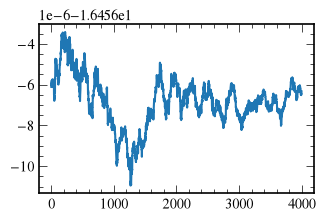

In [52]:
plt.plot(samples['xs'][:, 4])
plt.show()

In [44]:
len(psrs)

2

## Blocked Gibbs

In [88]:
site = tuple(['z_tm_concat'])  # convert list -> tuple, no extra wrapping
kernel = MultiHMCGibbsWithAnalytic(
        [numpyro.infer.NUTS(
                model=model,
                # dense_mass=[site],
                adapt_mass_matrix=True,
                # inverse_mass_matrix={site: tm_model.aux_list[0]['mle']['cov']}
                ),
        numpyro.infer.NUTS(model), 
        ],
        
        [
        ['z_tm_concat'],
        ['theta_wn', 'xs', 'z_a']
        ]
    )

# kernel = NUTS(model, max_tree_depth=8, target_accept_prob=0.8, dense_mass=False)

In [89]:
mcmc = numpyro.infer.MCMC(
    sampler=kernel,
    num_warmup=1000,
    num_samples=4000,
    num_chains=1,
)

mcmc.run(jrandom.key(170817))
samples = mcmc.get_samples()

sample: 100%|████████████████████████████████████████████████████████████████████| 5000/5000 [16:54<00:00,  4.93it/s, 31/63 steps of size 1.60e-01/6.31e-02. acc. prob=0.94/0.96]


In [44]:
x0.shape

(2,)

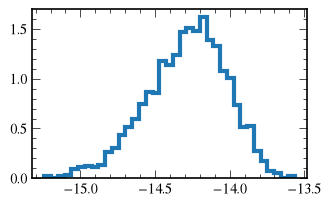

In [46]:
plt.hist(samples['xs'][:, 0], **hist_settings)
plt.show()